# Auto Insurance Claim-Frequency Modeling
### A small, honest, end-to-end project — built for understanding the problem space

**Business framing.** Insurers price a policy roughly as:

$$\text{Pure Premium} = \text{Claim Frequency} \times \text{Claim Severity}$$

This project models the **frequency** half: *how likely is a given policy to file at least one claim?*
That single question sits at the heart of auto-insurance pricing and underwriting.

**Dataset.** French Motor Third-Party Liability (`freMTPL2freq`) — the canonical public
auto-insurance dataset, loaded from OpenML. If OpenML is unreachable the notebook
auto-generates a synthetic dataset with the *same schema* so everything still runs.

**What this notebook demonstrates (the three things the role cares about):**
1. **Clean modeling + honest evaluation** — an interpretable GLM baseline vs. gradient boosting, judged on the *right* metrics for a rare-event problem.
2. **Business communication** — feature importance + a plain-English summary for a non-technical pricing partner.
3. **Sound engineering** — a reusable pipeline module (`claim_pipeline.py`) shared with a deployed Streamlit app.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import claim_pipeline as cp   # shared logic, also used by the Streamlit app

pd.set_option("display.max_columns", 30)
RANDOM_STATE = cp.RANDOM_STATE

## 2. Load the data

We try the real `freMTPL2freq` dataset first. The `source` string tells you whether you
got the real data or the synthetic stand-in — mention this honestly if asked.

In [2]:
df, source = cp.load_data()
print("Data source:", source)
print("Rows:", len(df))
df.head()

Data source: REAL freMTPL2freq (OpenML)
Rows: 678013


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


## 3. Exploratory data analysis

A few things an insurance data scientist looks for immediately:
- **How rare are claims?** (This decides which metrics matter.)
- **Exposure** — policies aren't all active for a full year. A 6-month policy (Exposure=0.5)
  has less opportunity to claim. Real actuarial models use exposure as an *offset*; we keep
  it visible here so you can speak to it.
- **Driver age** — classic U-shaped risk (young and very old drivers tend to be riskier).

Share of policies with >=1 claim: 5.00%
Mean exposure (years): 0.50


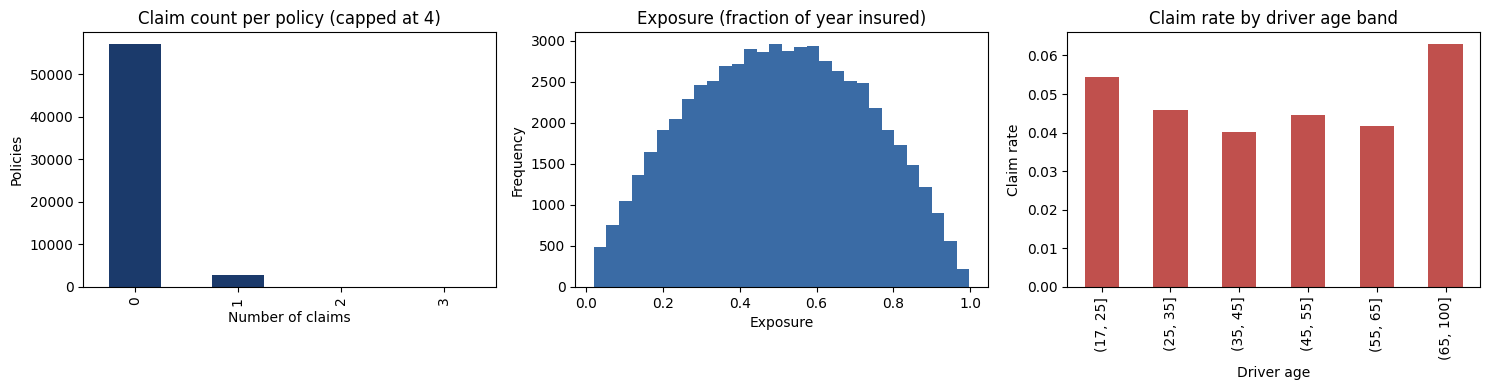

In [3]:
claim_rate = (df["ClaimNb"] > 0).mean()
print(f"Share of policies with >=1 claim: {claim_rate:.2%}")
print(f"Mean exposure (years): {df['Exposure'].mean():.2f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df["ClaimNb"].clip(upper=4).value_counts().sort_index().plot(
    kind="bar", ax=ax[0], color="#1B3A6B")
ax[0].set_title("Claim count per policy (capped at 4)")
ax[0].set_xlabel("Number of claims"); ax[0].set_ylabel("Policies")

df["Exposure"].plot(kind="hist", bins=30, ax=ax[1], color="#3A6BA5")
ax[1].set_title("Exposure (fraction of year insured)")
ax[1].set_xlabel("Exposure")

# Empirical claim rate by driver-age band -- the U-shape pricing story.
band = pd.cut(df["DrivAge"], bins=[17,25,35,45,55,65,100])
(df.assign(band=band, claimed=(df["ClaimNb"]>0).astype(int))
   .groupby("band", observed=True)["claimed"].mean()
   .plot(kind="bar", ax=ax[2], color="#C0504D"))
ax[2].set_title("Claim rate by driver age band")
ax[2].set_xlabel("Driver age"); ax[2].set_ylabel("Claim rate")
plt.tight_layout(); plt.show()

**Talking point:** roughly 5–10% of policies file a claim in a year. That imbalance is
the single most important fact about this problem — it dictates everything about how we
evaluate the model below.

## 4. Prepare features and target

We turn the raw claim *count* into a clean binary target (`had a claim: yes/no`) for an
interpretable classification demo. We cap extreme claim counts and drop impossible rows —
the kind of defensive cleaning real data always needs.

In [4]:
X, y, df_clean = cp.prepare(df)
print("Features used:")
print("  numeric    :", cp.NUMERIC_FEATURES)
print("  categorical:", cp.CATEGORICAL_FEATURES)
print("Positive class rate:", round(y.mean(), 4))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print("Train / test sizes:", len(X_train), len(X_test))

Features used:
  numeric    : ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']
  categorical: ['VehBrand', 'VehGas', 'Region', 'Area']
Positive class rate: 0.05
Train / test sizes: 45000 15000


## 5. Train two models

**Why two?** Insurers don't always reach for the fanciest model. **GLMs (here, logistic
regression) are an industry standard** because regulators and actuaries need to *explain*
why a policy was priced the way it was. We use the GLM as an interpretable baseline, then
check whether **gradient boosting (XGBoost)** — which tends to win on tabular data — buys us
enough lift to justify its lower interpretability.

Both models are told about the class imbalance (`class_weight='balanced'` /
`scale_pos_weight`) so they don't simply predict "no claim" for everyone.

In [5]:
models = cp.train_models(X_train, y_train)
print("Trained:", list(models.keys()))

Trained: ['GLM (Logistic Regression)', 'XGBoost']


## 6. Evaluation — on the metrics that actually matter

**The rare-event trap (say this in the interview):** with claims this rare, a model that
predicts *"no claim, ever"* is ~90%+ accurate and completely useless. **Accuracy is the wrong
metric.** We care about:
- **ROC-AUC / PR-AUC** — ranking ability across all thresholds.
- **Precision vs. Recall** — and the *business* tradeoff between them. The right operating
  threshold depends on the cost of acting on a false positive vs. missing a real risk.

In [6]:
rows = []
proba = {}
for name, m in models.items():
    res = cp.evaluate(m, X_test, y_test)
    proba[name] = res.pop("_proba")
    rows.append({"Model": name, **res})
results = pd.DataFrame(rows).set_index("Model")
results.style.format("{:.4f}").background_gradient(cmap="Blues", axis=0)

,Accuracy (misleading here!),ROC-AUC,PR-AUC (avg precision),Precision,Recall,F1
Model,,,,,,
GLM (Logistic Regression),0.5855,0.5947,0.0690,0.0652,0.5467,0.1165
XGBoost,0.6987,0.5766,0.0636,0.0694,0.4053,0.1186


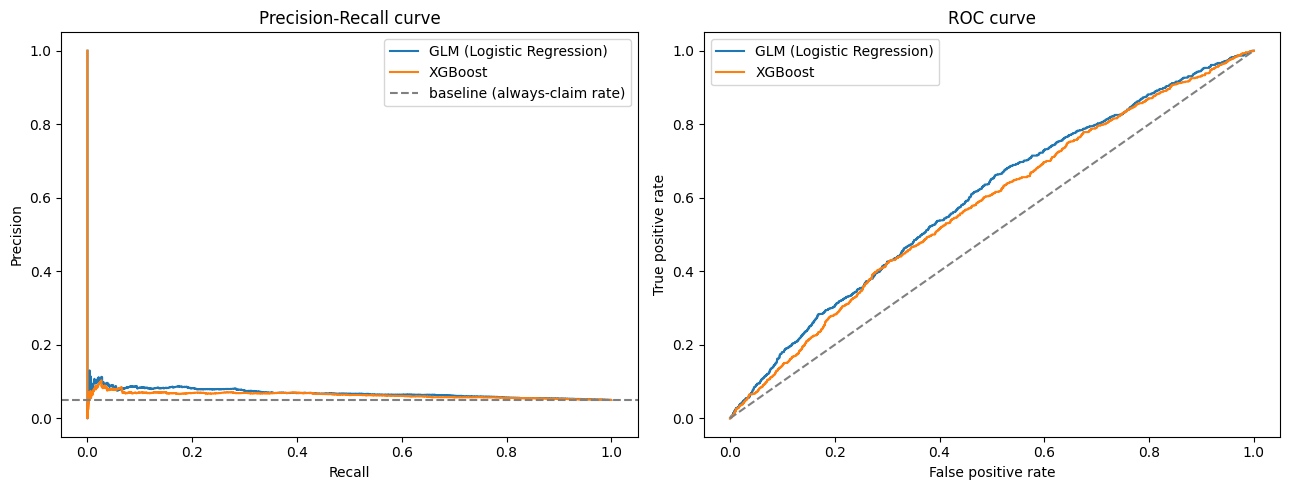

In [7]:
# Precision-Recall curves -- the right picture for an imbalanced problem.
from sklearn.metrics import precision_recall_curve, roc_curve

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name in models:
    p, r, _ = precision_recall_curve(y_test, proba[name])
    ax[0].plot(r, p, label=name)
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    ax[1].plot(fpr, tpr, label=name)
ax[0].axhline(y_test.mean(), ls="--", c="grey", label="baseline (always-claim rate)")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
ax[0].set_title("Precision-Recall curve"); ax[0].legend()
ax[1].plot([0,1],[0,1], ls="--", c="grey")
ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate")
ax[1].set_title("ROC curve"); ax[1].legend()
plt.tight_layout(); plt.show()

**Reading the results honestly:** claim frequency is *intrinsically hard* to predict —
most of the signal in who-claims is genuinely random. An AUC in the low-to-mid 0.6s is
realistic and respectable for this dataset. A junior candidate reports 99% accuracy and
thinks they won; a strong one explains *why that number would be a lie* and reports the
honest, lower AUC instead. Be the second candidate.

## 7. What drives claim risk? (business communication)

A pricing manager doesn't want coefficients — they want *"which factors push a policy's risk
up or down?"* We pull the GLM's standardized coefficients (directional, interpretable) and
XGBoost's feature importances (predictive contribution).

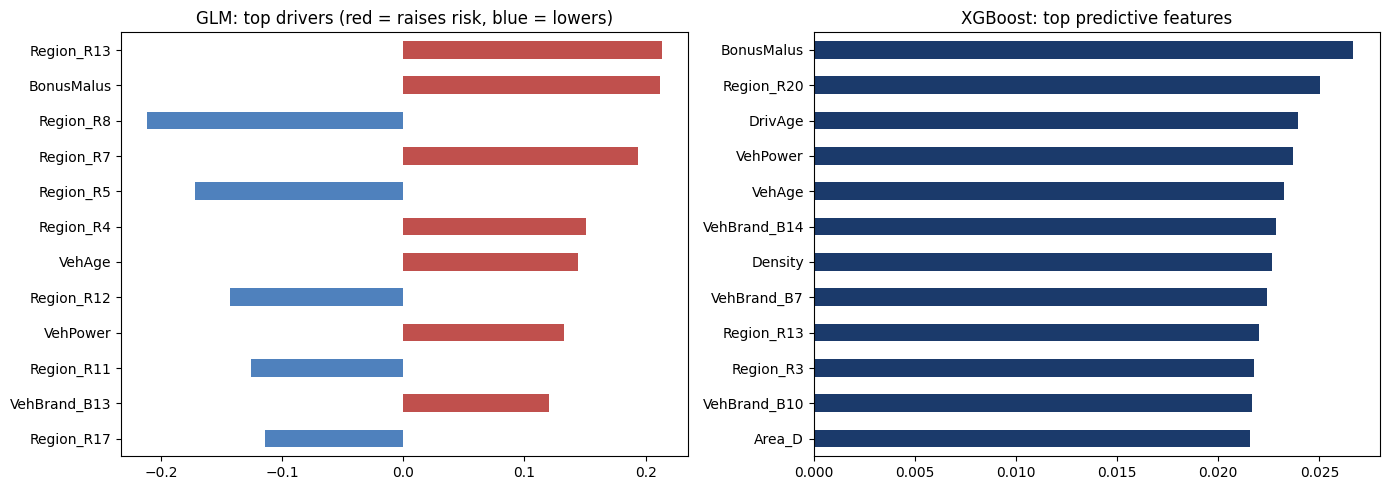

In [8]:
# GLM coefficients -- signed & interpretable.
glm = models["GLM (Logistic Regression)"]
glm_names = cp.feature_names(glm)
coefs = glm.named_steps["clf"].coef_[0]
glm_imp = (pd.Series(coefs, index=glm_names)
           .reindex(pd.Series(coefs, index=glm_names).abs().sort_values(ascending=False).index)
           .head(12))

# XGBoost importances.
xgb = models["XGBoost"]
xgb_names = cp.feature_names(xgb)
xgb_imp = (pd.Series(xgb.named_steps["clf"].feature_importances_, index=xgb_names)
           .sort_values(ascending=False).head(12))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
glm_imp[::-1].plot(kind="barh", ax=ax[0],
                   color=["#C0504D" if v>0 else "#4F81BD" for v in glm_imp[::-1]])
ax[0].set_title("GLM: top drivers (red = raises risk, blue = lowers)")
xgb_imp[::-1].plot(kind="barh", ax=ax[1], color="#1B3A6B")
ax[1].set_title("XGBoost: top predictive features")
plt.tight_layout(); plt.show()

## 8. The one-paragraph stakeholder summary

> *"On a public motor-insurance dataset, I built a model that estimates each policy's
> probability of filing a claim — the frequency component of pricing. Because claims are rare
> (~5–10% of policies), I evaluated it on ranking and precision/recall rather than accuracy,
> which would be misleading here. The strongest risk signals were the bonus-malus score,
> driver age, and population density of the area — all consistent with how the business
> already thinks about risk. An interpretable GLM and a gradient-boosting model performed
> comparably, so for a regulated pricing use case I'd lean toward the GLM for explainability,
> and reserve boosting for places where the extra lift is worth the lower transparency."*

That paragraph is your project, compressed to interview-speaking length. If you remember one
thing from this notebook, remember that paragraph.

## 9. Save the model for the Streamlit app (deployment)
We persist the better-ranking model so the companion `app.py` can serve live risk scores.

In [9]:
import joblib
best_name = results["ROC-AUC"].idxmax()
joblib.dump(models[best_name], "claim_model.joblib")
print(f"Saved '{best_name}' -> claim_model.joblib")
print("Run the live scorer with:  streamlit run app.py")

Saved 'GLM (Logistic Regression)' -> claim_model.joblib
Run the live scorer with:  streamlit run app.py


## 10. Honest limitations (say these before they ask)
- **Frequency only** — a full pricing model also needs claim *severity* (a regression on
  claim amount), then combines the two.
- **Exposure** is used as a feature here; a production actuarial model would use it as a
  Poisson *offset* and likely model the claim *count* directly (Poisson/Tweedie GLM).
- **No fairness/regulatory review** — real insurance models face strict scrutiny on which
  variables are permissible and on disparate impact.
- **Modest AUC** — expected for this problem; the value is in the framing and rigor, not a
  headline accuracy number.

Naming your own limitations is the most senior thing you can do in an interview.